In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
from sklearn import datasets
import numpy as np

In [3]:
s = 'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'

In [4]:
df2 = pd.read_csv(s, encoding='utf_8')
df2.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
print(df2.head())

   sepal_length  sepal_width  petal_length  petal_width      species
0           4.9          3.0           1.4          0.2  Iris-setosa
1           4.7          3.2           1.3          0.2  Iris-setosa
2           4.6          3.1           1.5          0.2  Iris-setosa
3           5.0          3.6           1.4          0.2  Iris-setosa
4           5.4          3.9           1.7          0.4  Iris-setosa


In [5]:
df = pd.read_csv(s, header=None, encoding='utf_8')
print(df.head())

     0    1    2    3            4
0  5.1  3.5  1.4  0.2  Iris-setosa
1  4.9  3.0  1.4  0.2  Iris-setosa
2  4.7  3.2  1.3  0.2  Iris-setosa
3  4.6  3.1  1.5  0.2  Iris-setosa
4  5.0  3.6  1.4  0.2  Iris-setosa


In [6]:
p0 = df.iloc[0:100, 4]
print(p0)

0         Iris-setosa
1         Iris-setosa
2         Iris-setosa
3         Iris-setosa
4         Iris-setosa
           ...       
95    Iris-versicolor
96    Iris-versicolor
97    Iris-versicolor
98    Iris-versicolor
99    Iris-versicolor
Name: 4, Length: 100, dtype: str


In [7]:
p = df.iloc[0:100, 4]
print(p)

0         Iris-setosa
1         Iris-setosa
2         Iris-setosa
3         Iris-setosa
4         Iris-setosa
           ...       
95    Iris-versicolor
96    Iris-versicolor
97    Iris-versicolor
98    Iris-versicolor
99    Iris-versicolor
Name: 4, Length: 100, dtype: str


In [8]:

y = p.values
print(y)

<StringArray>
[    'Iris-setosa',     'Iris-setosa',     'Iris-setosa',     'Iris-setosa',
     'Iris-setosa',     'Iris-setosa',     'Iris-setosa',     'Iris-setosa',
     'Iris-setosa',     'Iris-setosa',     'Iris-setosa',     'Iris-setosa',
     'Iris-setosa',     'Iris-setosa',     'Iris-setosa',     'Iris-setosa',
     'Iris-setosa',     'Iris-setosa',     'Iris-setosa',     'Iris-setosa',
     'Iris-setosa',     'Iris-setosa',     'Iris-setosa',     'Iris-setosa',
     'Iris-setosa',     'Iris-setosa',     'Iris-setosa',     'Iris-setosa',
     'Iris-setosa',     'Iris-setosa',     'Iris-setosa',     'Iris-setosa',
     'Iris-setosa',     'Iris-setosa',     'Iris-setosa',     'Iris-setosa',
     'Iris-setosa',     'Iris-setosa',     'Iris-setosa',     'Iris-setosa',
     'Iris-setosa',     'Iris-setosa',     'Iris-setosa',     'Iris-setosa',
     'Iris-setosa',     'Iris-setosa',     'Iris-setosa',     'Iris-setosa',
     'Iris-setosa',     'Iris-setosa', 'Iris-versicolor', 'Iri

In [9]:
y = np.where(y == 'Iris-setosa', 0, 1)
print(y)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [10]:
X = df.iloc[0:100, [0,2]]
print(X)

      0    2
0   5.1  1.4
1   4.9  1.4
2   4.7  1.3
3   4.6  1.5
4   5.0  1.4
..  ...  ...
95  5.7  4.2
96  5.7  4.2
97  6.2  4.3
98  5.1  3.0
99  5.7  4.1

[100 rows x 2 columns]


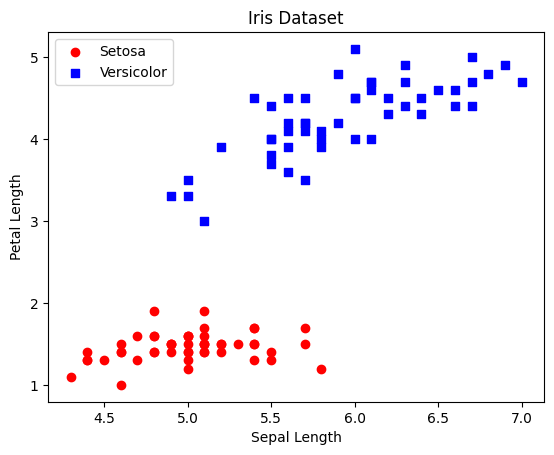

In [11]:
plt.scatter(X.iloc[:50, 0], X.iloc[:50, 1], color='red', marker='o', label='Setosa')
plt.scatter(X.iloc[50:100, 0], X.iloc[50:100, 1], color='blue', marker='s', label='Versicolor')
plt.xlabel('Sepal Length')
plt.ylabel('Petal Length')
plt.title('Iris Dataset')
plt.legend()
plt.show()

In [12]:
import perceptron

In [13]:
print(X.shape)
print(y.shape)

(100, 2)
(100,)


In [14]:
X = np.asarray(X, dtype=float)
y = np.asarray(y).ravel()

In [15]:
print(X.shape)
print(y.shape)

(100, 2)
(100,)


In [16]:
ppn = perceptron.Perceptron(eta=0.1, num_epochs=10)
ppn.fit(X, y)

In [17]:
print(ppn.num_epochs)

10


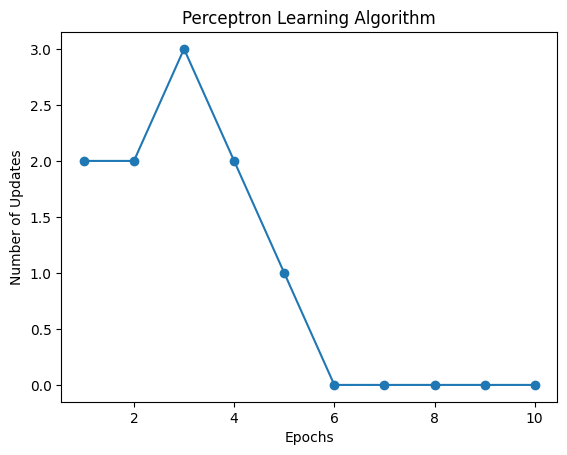

In [18]:
plt.plot(range(1, len(ppn.errors) + 1), ppn.errors, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Number of Updates')
plt.title('Perceptron Learning Algorithm')
plt.show()

In [19]:
from pathlib import Path
import sys

sys.path.append(str(Path.cwd().parent))

from shared import utils

/tmp/ipykernel_971126/592923538.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper left')


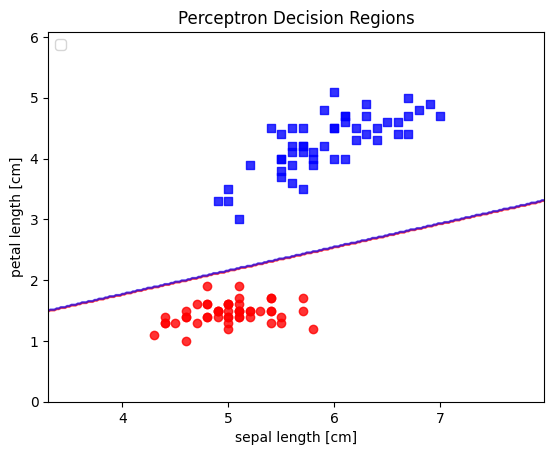

In [20]:
utils.plot_decision_regions(X, y, ppn)
plt.xlabel('sepal length [cm]')
plt.ylabel('petal length [cm]')
plt.legend(loc='upper left')
plt.title('Perceptron Decision Regions')
plt.show()

In [21]:
x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, 0.02), np.arange(x2_min, x2_max, 0.02))


In [22]:
print(xx1.shape)
print(xx2.shape)

(305, 235)
(305, 235)


In [23]:
print(xx1[:10])
print(xx2[:10])

[[3.3  3.32 3.34 ... 7.94 7.96 7.98]
 [3.3  3.32 3.34 ... 7.94 7.96 7.98]
 [3.3  3.32 3.34 ... 7.94 7.96 7.98]
 ...
 [3.3  3.32 3.34 ... 7.94 7.96 7.98]
 [3.3  3.32 3.34 ... 7.94 7.96 7.98]
 [3.3  3.32 3.34 ... 7.94 7.96 7.98]]
[[0.   0.   0.   ... 0.   0.   0.  ]
 [0.02 0.02 0.02 ... 0.02 0.02 0.02]
 [0.04 0.04 0.04 ... 0.04 0.04 0.04]
 ...
 [0.14 0.14 0.14 ... 0.14 0.14 0.14]
 [0.16 0.16 0.16 ... 0.16 0.16 0.16]
 [0.18 0.18 0.18 ... 0.18 0.18 0.18]]


In [38]:

from matplotlib.colors import ListedColormap


def plot_decision_regions_ipynb(X, y, classifier, resolution=0.02):
    markers = ('o', 's', '^', 'v', '<')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))

    lab = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    lab = lab.reshape(xx1.shape)

    plt.contourf(xx1, xx2, lab, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    for idx, c1 in enumerate(np.unique(y)):
        plt.scatter(x=X[y == c1, 0], y=X[y == c1, 1], alpha=0.8, c=colors[idx], marker=markers[idx])
    

/tmp/ipykernel_971126/2290481507.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper left')


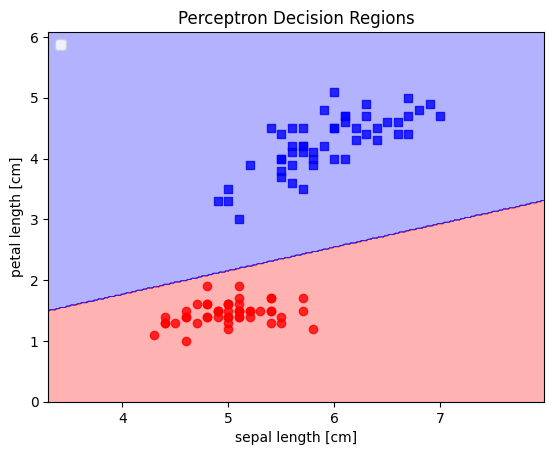

In [39]:
plot_decision_regions_ipynb(X, y, ppn)
plt.xlabel('sepal length [cm]')
plt.ylabel('petal length [cm]')
plt.legend(loc='upper left')
plt.title('Perceptron Decision Regions')
plt.show()